In [1]:
# Basic libraries
import pandas as pd # used for data loading,cleaning and manipulation
import numpy as np # used for mathematical and numerical operations
import seaborn as sns #used for advanced  data visualization
import matplotlib.pyplot as plt # used for ploting graphs and charts

# Train-test split
from sklearn.model_selection import train_test_split

# Machine Learning models
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression # baseline classification model
from sklearn.tree import DecisionTreeClassifier # tree based classification model
from sklearn.ensemble import RandomForestClassifier # ensemble model for high accuracy
from xgboost import XGBClassifier # XGBoost advanced algorithm

# Evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

# Save model
import pickle


In [3]:
# Load dataset
df = pd.read_csv('data.csv')

# Check shape
print("Dataset shape:", df.shape)

# View first 5 rows
df.head()

Dataset shape: (23634, 16)


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,c12e07a0-8a06-4c0d-b5cc-04f3af688570,8ca9f102-02a4-4207-ab63-484e83a1bdf0,42.32,2024-03-24 23:42:43,PayPal,electronics,1,40,East Jameshaven,desktop,110.87.246.85,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,5399 Rachel Stravenue Suite 718\nNorth Blakebu...,0,282,23
1,7d187603-7961-4fce-9827-9698e2b6a201,4d158416-caae-4b09-bd5b-15235deb9129,301.34,2024-01-22 00:53:31,credit card,electronics,3,35,Kingstad,tablet,14.73.104.153,"5230 Stephanie Forge\nCollinsbury, PR 81853","5230 Stephanie Forge\nCollinsbury, PR 81853",0,223,0
2,f2c14f9d-92df-4aaf-8931-ceaf4e63ed72,ccae47b8-75c7-4f5a-aa9e-957deced2137,340.32,2024-01-22 08:06:03,debit card,toys & games,5,29,North Ryan,desktop,67.58.94.93,"195 Cole Oval\nPort Larry, IA 58422","4772 David Stravenue Apt. 447\nVelasquezside, ...",0,360,8
3,e9949bfa-194d-486b-84da-9565fca9e5ce,b04960c0-aeee-4907-b1cd-4819016adcef,95.77,2024-01-16 20:34:53,credit card,electronics,5,45,Kaylaville,mobile,202.122.126.216,"7609 Cynthia Square\nWest Brenda, NV 23016","7609 Cynthia Square\nWest Brenda, NV 23016",0,325,20
4,7362837c-7538-434e-8731-0df713f5f26d,de9d6351-b3a7-4bc7-9a55-8f013eb66928,77.45,2024-01-16 15:47:23,credit card,clothing,5,42,North Edwardborough,desktop,96.77.232.76,"2494 Robert Ramp Suite 313\nRobinsonport, AS 5...","2494 Robert Ramp Suite 313\nRobinsonport, AS 5...",0,116,15


In [7]:
df.tail()

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
23629,d8b7171f-bdd9-479c-b98b-396c621aebfe,98a3d94c-dc9a-4525-b273-e6ffe54cc5a4,53.73,2024-01-26 16:25:05,PayPal,toys & games,5,32,Rebeccafurt,tablet,173.97.197.128,USNV Clayton\nFPO AE 82639,USNV Clayton\nFPO AE 82639,0,363,16
23630,0fd12cf3-c641-4499-8de1-15dc4555cb0c,b3429f52-8b27-46b5-914c-4accd989edb4,47.42,2024-02-25 17:03:26,credit card,clothing,4,41,Nataliefort,desktop,133.222.22.48,"9288 Patricia Cape Apt. 527\nMelissaton, IL 38543","9288 Patricia Cape Apt. 527\nMelissaton, IL 38543",0,296,17
23631,649680d3-a684-44cb-95bf-9b454c3aa86d,066e25c9-4420-4224-bc3f-1a462708090e,1045.23,2024-03-28 23:46:47,bank transfer,health & beauty,1,9,East Shannonville,tablet,206.133.237.168,3015 Elizabeth Summit Suite 819\nEast Joelfort...,3015 Elizabeth Summit Suite 819\nEast Joelfort...,0,329,23
23632,c10dbb08-28fc-4ec1-9850-d4e98d2b9640,cde96e9c-f562-4b8c-8fa8-f356f474232b,34.25,2024-02-09 11:29:18,debit card,home & garden,2,39,Lake Nicole,mobile,16.204.137.130,"531 Brittany Pike\nNew Stacy, OR 87952","531 Brittany Pike\nNew Stacy, OR 87952",0,347,11
23633,23e3c107-f2fc-48c2-abbc-7b809bf6f102,d8d7a64e-8419-4421-910a-a7cf709a900b,85.03,2024-01-23 02:46:52,credit card,clothing,4,38,Holtport,tablet,116.188.254.162,"289 Adams Wells\nWest Joeltown, LA 69190","289 Adams Wells\nWest Joeltown, LA 69190",0,203,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23634 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      23634 non-null  object 
 1   Customer ID         23634 non-null  object 
 2   Transaction Amount  23634 non-null  float64
 3   Transaction Date    23634 non-null  object 
 4   Payment Method      23634 non-null  object 
 5   Product Category    23634 non-null  object 
 6   Quantity            23634 non-null  int64  
 7   Customer Age        23634 non-null  int64  
 8   Customer Location   23634 non-null  object 
 9   Device Used         23634 non-null  object 
 10  IP Address          23634 non-null  object 
 11  Shipping Address    23634 non-null  object 
 12  Billing Address     23634 non-null  object 
 13  Is Fraudulent       23634 non-null  int64  
 14  Account Age Days    23634 non-null  int64  
 15  Transaction Hour    23634 non-null  int64  
dtypes: f

In [5]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000,23634.000000
mean,229.367099,3.000550,34.560210,0.051705,178.660531,11.266015
std,282.046669,1.419663,10.009471,0.221436,107.388682,6.980659
min,10.000000,1.000000,-2.000000,0.000000,1.000000,0.000000
25%,69.070000,2.000000,28.000000,0.000000,84.000000,5.000000
50%,151.415000,3.000000,35.000000,0.000000,178.000000,11.000000
75%,296.127500,4.000000,41.000000,0.000000,272.000000,17.000000
max,9716.500000,5.000000,73.000000,1.000000,365.000000,23.000000


In [6]:
df.describe(include='O')

,Transaction ID,Customer ID,Transaction Date,Payment Method,Product Category,Customer Location,Device Used,IP Address,Shipping Address,Billing Address
count,23634,23634,23634,23634,23634,23634,23634,23634,23634,23634
unique,23634,23634,23607,4,5,14868,3,23634,23634,23634
top,23e3c107-f2fc-48c2-abbc-7b809bf6f102,d8d7a64e-8419-4421-910a-a7cf709a900b,2024-02-04 21:23:35,debit card,home & garden,North Michael,desktop,116.188.254.162,"289 Adams Wells\nWest Joeltown, LA 69190","289 Adams Wells\nWest Joeltown, LA 69190"
freq,1,1,2,5952,4786,30,7923,1,1,1


In [8]:
df.isnull().sum()

Transaction ID        0
Customer ID           0
Transaction Amount    0
Transaction Date      0
Payment Method        0
Product Category      0
Quantity              0
Customer Age          0
Customer Location     0
Device Used           0
IP Address            0
Shipping Address      0
Billing Address       0
Is Fraudulent         0
Account Age Days      0
Transaction Hour      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Transaction Amount'),
  Text(1, 0, 'Quantity'),
  Text(2, 0, 'Customer Age'),
  Text(3, 0, 'Is Fraudulent'),
  Text(4, 0, 'Account Age Days'),
  Text(5, 0, 'Transaction Hour')])

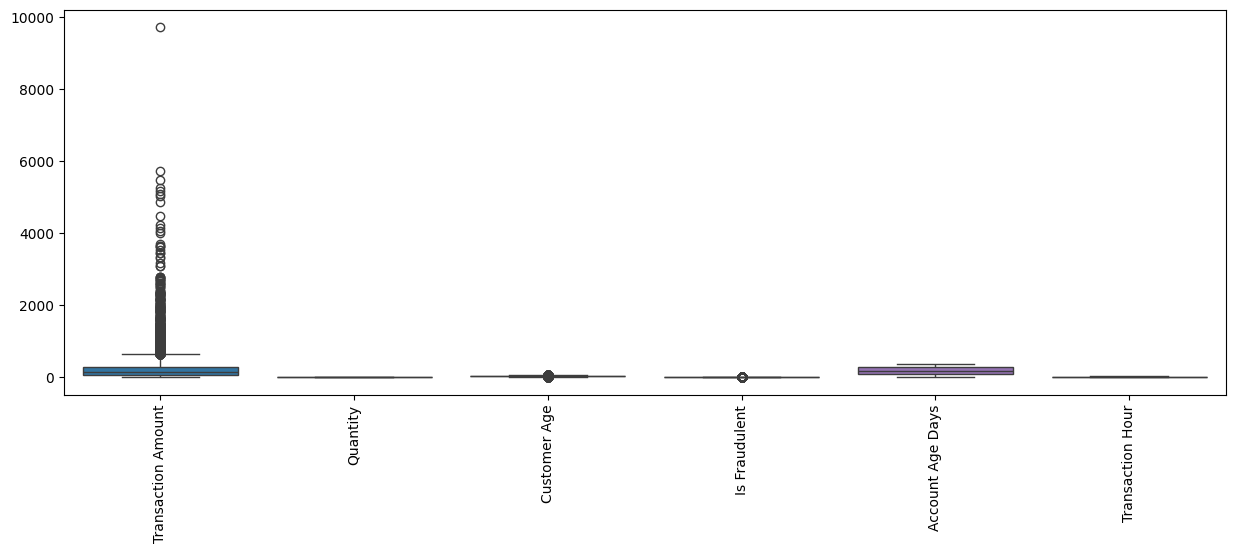

In [10]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)

In [11]:
x=['Transaction Amount','Customer Age','Is Fraudulent']
for i in x:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1   
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)]
    percentage_outliers = (len(outliers) / len(df)) * 100
    print(f"Percentage of outliers in {i}: {percentage_outliers:.2f}%")

Percentage of outliers in Transaction Amount: 5.67%
Percentage of outliers in Customer Age: 0.96%
Percentage of outliers in Is Fraudulent: 5.17%


In [12]:
if percentage_outliers<=5:
        outliers_handled= data[~((df[i] < lower_bound) | (df[i] > upper_bound))]
        print(f'Outliers handled for {i}, percentage of outliers: {percentage_outliers:.2f}%')

In [13]:
# Drop unnecessary columns
df.drop(columns=['Transaction ID','Customer ID','Quantity','IP Address','Shipping Address','Billing Address','Customer Location'], inplace=True, errors='ignore')

In [14]:
df

,Transaction Amount,Transaction Date,Payment Method,Product Category,Customer Age,Device Used,Is Fraudulent,Account Age Days,Transaction Hour
0,42.32,2024-03-24 23:42:43,PayPal,electronics,40,desktop,0,282,23
1,301.34,2024-01-22 00:53:31,credit card,electronics,35,tablet,0,223,0
2,340.32,2024-01-22 08:06:03,debit card,toys & games,29,desktop,0,360,8
3,95.77,2024-01-16 20:34:53,credit card,electronics,45,mobile,0,325,20
4,77.45,2024-01-16 15:47:23,credit card,clothing,42,desktop,0,116,15
...,...,...,...,...,...,...,...,...,...
23629,53.73,2024-01-26 16:25:05,PayPal,toys & games,32,tablet,0,363,16
23630,47.42,2024-02-25 17:03:26,credit card,clothing,41,desktop,0,296,17
23631,1045.23,2024-03-28 23:46:47,bank transfer,health & beauty,9,tablet,0,329,23
23632,34.25,2024-02-09 11:29:18,debit card,home & garden,39,mobile,0,347,11


In [15]:
# Convert datetime and extract hour
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Transaction Hour'] = df['Transaction Date'].dt.hour
df.drop(columns=['Transaction Date'], inplace=True)

In [16]:
df

,Transaction Amount,Payment Method,Product Category,Customer Age,Device Used,Is Fraudulent,Account Age Days,Transaction Hour
0,42.32,PayPal,electronics,40,desktop,0,282,23
1,301.34,credit card,electronics,35,tablet,0,223,0
2,340.32,debit card,toys & games,29,desktop,0,360,8
3,95.77,credit card,electronics,45,mobile,0,325,20
4,77.45,credit card,clothing,42,desktop,0,116,15
...,...,...,...,...,...,...,...,...
23629,53.73,PayPal,toys & games,32,tablet,0,363,16
23630,47.42,credit card,clothing,41,desktop,0,296,17
23631,1045.23,bank transfer,health & beauty,9,tablet,0,329,23
23632,34.25,debit card,home & garden,39,mobile,0,347,11


In [17]:
df['Payment Method'].value_counts()

Payment Method
debit card       5952
credit card      5923
PayPal           5899
bank transfer    5860
Name: count, dtype: int64

In [18]:
df['Product Category'].value_counts()

Product Category
home & garden      4786
electronics        4748
toys & games       4730
clothing           4699
health & beauty    4671
Name: count, dtype: int64

In [19]:
df['Device Used'].value_counts()

Device Used
desktop    7923
mobile     7881
tablet     7830
Name: count, dtype: int64

In [20]:
# Encode categorical columns
cat_cols = ['Payment Method', 'Product Category', 'Device Used']
df_encoded = pd.get_dummies(df, columns=cat_cols)

# Define features and target
X = df_encoded.drop('Is Fraudulent', axis=1)
y = df_encoded['Is Fraudulent']

In [21]:
X

,Transaction Amount,Customer Age,Account Age Days,Transaction Hour,Payment Method_PayPal,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_clothing,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_desktop,Device Used_mobile,Device Used_tablet
0,42.32,40,282,23,True,False,False,False,False,True,False,False,False,True,False,False
1,301.34,35,223,0,False,False,True,False,False,True,False,False,False,False,False,True
2,340.32,29,360,8,False,False,False,True,False,False,False,False,True,True,False,False
3,95.77,45,325,20,False,False,True,False,False,True,False,False,False,False,True,False
4,77.45,42,116,15,False,False,True,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23629,53.73,32,363,16,True,False,False,False,False,False,False,False,True,False,False,True
23630,47.42,41,296,17,False,False,True,False,True,False,False,False,False,True,False,False
23631,1045.23,9,329,23,False,True,False,False,False,False,True,False,False,False,False,True
23632,34.25,39,347,11,False,False,False,True,False,False,False,True,False,False,True,False


In [22]:
y

0        0
1        0
2        0
3        0
4        0
        ..
23629    0
23630    0
23631    0
23632    0
23633    0
Name: Is Fraudulent, Length: 23634, dtype: int64

LGBMClassifier

In [23]:
#LGBMClassifier
from lightgbm import LGBMClassifier
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMClassifier()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

# Metrics
matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
r1 = recall_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
classify = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", matrix)
print("Accuracy:", acc)
print("Recall:", r1)
print("Precision:", pre)
print("F1-score:", f1)
print("Classification Report:\n", classify)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 980, number of negative: 17927
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 612
[LightGBM] [Info] Number of data points in the train set: 18907, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.051833 -> initscore=-2.906511
[LightGBM] [Info] Start training from score -2.906511
Confusion Matrix:
 [[4479    6]
 [ 215   27]]
Accuracy: 0.9532473027290036
Recall: 0.1115702479338843
Precision: 0.8181818181818182
F1-score: 0.19636363636363635
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      4485
           1       0.82      0.11      0.20       242

    accuracy                           0.95      4727
   macro avg       0.89  

Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(criterion="entropy",max_depth=3)
dtc.fit(X_train,y_train)
dtc_y_pred=dtc.predict(X_test)

matrix = confusion_matrix(y_test, dtc_y_pred)
acc = accuracy_score(y_test, dtc_y_pred)
r1 = recall_score(y_test, dtc_y_pred)
pre = precision_score(y_test, dtc_y_pred)
f1 = f1_score(y_test, dtc_y_pred)
classify = classification_report(y_test, dtc_y_pred)

print("Decision Tree")
print("Confusion Matrix:\n", matrix)
print("Accuracy:", acc)
print("Recall:", r1)
print("Precision:", pre)
print("F1-score:", f1)
print("Classification Report:\n", classify)

Decision Tree
Confusion Matrix:
 [[4479    6]
 [ 216   26]]
Accuracy: 0.953035752062619
Recall: 0.10743801652892562
Precision: 0.8125
F1-score: 0.1897810218978102
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      4485
           1       0.81      0.11      0.19       242

    accuracy                           0.95      4727
   macro avg       0.88      0.55      0.58      4727
weighted avg       0.95      0.95      0.94      4727



RandomForest Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(criterion="gini",max_depth=3)
rfc.fit(X_train,y_train)
rfc_pred=rfc.predict(X_test)

matrix = confusion_matrix(y_test, rfc_pred)
acc = accuracy_score(y_test, rfc_pred)
r1 = recall_score(y_test, rfc_pred)
pre = precision_score(y_test, rfc_pred)
f1 = f1_score(y_test, rfc_pred)
classify = classification_report(y_test, rfc_pred)

print("Decision Tree")
print("Confusion Matrix:\n", matrix)
print("Accuracy:", acc)
print("Recall:", r1)
print("Precision:", pre)
print("F1-score:", f1)
print("Classification Report:\n", classify)


Decision Tree
Confusion Matrix:
 [[4484    1]
 [ 227   15]]
Accuracy: 0.9517664480643114
Recall: 0.06198347107438017
Precision: 0.9375
F1-score: 0.11627906976744186
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      4485
           1       0.94      0.06      0.12       242

    accuracy                           0.95      4727
   macro avg       0.94      0.53      0.55      4727
weighted avg       0.95      0.95      0.93      4727



XGBoost

In [28]:
from xgboost import XGBClassifier
xgbmodel = XGBClassifier(n_estimators=10,max_depth=6,learning_rate=0.1,subsample=0.8)
xgbmodel.fit(X_train, y_train)
xg_pred = xgbmodel.predict(X_test)

matrix = confusion_matrix(y_test, xg_pred)
acc = accuracy_score(y_test, xg_pred)
r1 = recall_score(y_test, xg_pred)
pre = precision_score(y_test, xg_pred)
f1 = f1_score(y_test, xg_pred)
classify = classification_report(y_test, xg_pred)

print("Decision Tree")
print("Confusion Matrix:\n", matrix)
print("Accuracy:", acc)
print("Recall:", r1)
print("Precision:", pre)
print("F1-score:", f1)
print("Classification Report:\n", classify)

Decision Tree
Confusion Matrix:
 [[4483    2]
 [ 227   15]]
Accuracy: 0.9515548973979268
Recall: 0.06198347107438017
Precision: 0.8823529411764706
F1-score: 0.11583011583011583
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      4485
           1       0.88      0.06      0.12       242

    accuracy                           0.95      4727
   macro avg       0.92      0.53      0.55      4727
weighted avg       0.95      0.95      0.93      4727

